# Explainability Framework — GNNExplainer + PGExplainer + Faithfulness

Builds a reusable framework that:
1. Loads each trained model (GCN, GraphSAGE, EvolveGCN)
2. Runs GNNExplainer and PGExplainer on 50 illicit + 50 licit predictions per model
3. Computes faithfulness metrics (fidelity+, fidelity-, sparsity)
4. Compares explanation patterns across classes and methods
5. Visualizes representative cases

In [2]:
# Cell 1 — Install PyG (rerun every session, takes ~2min)
import torch
TORCH = torch.__version__.split('+')[0]      # e.g. "2.4.0"
CUDA = 'cu' + torch.version.cuda.replace('.', '')  # e.g. "cu121"

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch_geometric torch_geometric_temporal


Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 148.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 140.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 108.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.3 MB/s eta 0:00:00
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached torch_geometric_temporal-0.56.2-py3-none-any.whl.metadata (1.9 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Using cached torch_geometric_temporal-0.56.2-py3-none-any.whl (102 kB)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/graphshield'
DATA_DIR    = f'{PROJECT_DIR}/data/raw/elliptic_bitcoin_dataset'
RESULTS_DIR = f'{PROJECT_DIR}/results'

import os
os.makedirs(RESULTS_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
# Cell 3 — Standard imports
import json, time, sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer, PGExplainer
from torch_geometric_temporal.nn.recurrent import EvolveGCNH

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Torch :', torch.__version__)

Device: cuda
Torch : 2.10.0+cu128


In [5]:
# Cell 4 — Import shared code from src/ (once you create it)
sys.path.append(f'{PROJECT_DIR}/src')
# from data.loaders import load_elliptic   # uncomment after you write it

## Load Elliptic and build the PyG Data object

Three CSVs:
- `elliptic_txs_features.csv` — col 0 = txId, col 1 = timestep, rest = features
- `elliptic_txs_edgelist.csv` — txId1, txId2
- `elliptic_txs_classes.csv` — txId, class ('1' illicit, '2' licit, 'unknown')

In [6]:
features_raw = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edges_raw    = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
classes_raw  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

print(f'features: {features_raw.shape}')
print(f'edges:    {edges_raw.shape}')
print(f'classes:  {classes_raw.shape}')
print()
print('class distribution:')
print(classes_raw['class'].value_counts())

features: (203769, 167)
edges:    (234355, 2)
classes:  (203769, 2)

class distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [7]:
# Name columns: 0=txId, 1=timestep, rest = features
n_features = features_raw.shape[1] - 2
features_raw.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(n_features)]
print(f'Number of node features: {n_features}')

# Map txId -> contiguous index 0..N-1
txid_to_idx = {txid: i for i, txid in enumerate(features_raw['txId'].values)}
N = len(txid_to_idx)
print(f'Num nodes: {N}')

# x and timesteps
timesteps = torch.tensor(features_raw['timestep'].values, dtype=torch.long)
x = torch.tensor(features_raw.iloc[:, 2:].values, dtype=torch.float)
print(f'x shape:   {tuple(x.shape)}')
print(f'timesteps: {int(timesteps.min())}..{int(timesteps.max())}')

Number of node features: 165
Num nodes: 203769
x shape:   (203769, 165)
timesteps: 1..49


In [8]:
# Drop edges referencing txIds not in features (defensive)
valid = edges_raw['txId1'].isin(txid_to_idx) & edges_raw['txId2'].isin(txid_to_idx)
edges_clean = edges_raw[valid]
print(f'Edges: {len(edges_raw)} raw -> {len(edges_clean)} after filtering')

src = edges_clean['txId1'].map(txid_to_idx).values
dst = edges_clean['txId2'].map(txid_to_idx).values
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)
print(f'edge_index shape: {tuple(edge_index.shape)}')

Edges: 234355 raw -> 234355 after filtering
edge_index shape: (2, 234355)


In [9]:
# Labels: '1' illicit -> 1, '2' licit -> 0, 'unknown' -> -1
def map_class(c):
    s = str(c).strip()
    if s == '1': return 1
    if s == '2': return 0
    return -1

classes_raw['label'] = classes_raw['class'].apply(map_class)
label_lookup = dict(zip(classes_raw['txId'], classes_raw['label']))

y = torch.tensor(
    [label_lookup.get(txid, -1) for txid in features_raw['txId'].values],
    dtype=torch.long,
)
print(f'Labels: licit={int((y==0).sum())}, illicit={int((y==1).sum())}, unknown={int((y==-1).sum())}')

Labels: licit=42019, illicit=4545, unknown=157205


In [10]:
# Three-way temporal split: 1-30 train, 31-34 val, 35-49 test
labeled    = (y != -1)
train_mask = labeled & (timesteps <= 30)
val_mask   = labeled & (timesteps >= 31) & (timesteps <= 34)
test_mask  = labeled & (timesteps >= 35)

print(f'Train : {int(train_mask.sum()):>6d} nodes  '
      f'(illicit={int((y[train_mask]==1).sum()):>4d}, '
      f'licit={int((y[train_mask]==0).sum()):>5d})')
print(f'Val   : {int(val_mask.sum()):>6d} nodes  '
      f'(illicit={int((y[val_mask]==1).sum()):>4d}, '
      f'licit={int((y[val_mask]==0).sum()):>5d})')
print(f'Test  : {int(test_mask.sum()):>6d} nodes  '
      f'(illicit={int((y[test_mask]==1).sum()):>4d}, '
      f'licit={int((y[test_mask]==0).sum()):>5d})')

data = Data(
    x=x, edge_index=edge_index, y=y,
    train_mask=train_mask, val_mask=val_mask, test_mask=test_mask,
    timesteps=timesteps,
).to(device)

Train :  26905 nodes  (illicit=2954, licit=23951)
Val   :   2989 nodes  (illicit= 508, licit= 2481)
Test  :  16670 nodes  (illicit=1083, licit=15587)


## Baseline 1 — Logistic Regression
Features only. Non-graph floor.

In [11]:
X_train = x[train_mask].numpy(); y_train = y[train_mask].numpy()
X_val   = x[val_mask].numpy();   y_val   = y[val_mask].numpy()
X_test  = x[test_mask].numpy();  y_test_np = y[test_mask].numpy()

scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

# Search over C using validation F1
from sklearn.metrics import f1_score
best_C, best_val_f1, best_clf = None, -1, None
for C in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', n_jobs=-1)
    clf.fit(X_train_s, y_train)
    val_preds = clf.predict(X_val_s)
    val_f1 = f1_score(y_val, val_preds, pos_label=1)
    print(f'  C={C:5.2f} | val illicit-F1={val_f1:.4f}')
    if val_f1 > best_val_f1:
        best_val_f1, best_C, best_clf = val_f1, C, clf

print(f'\nBest C={best_C} (val F1={best_val_f1:.4f}) — evaluating on test')

# Final test evaluation — touch test set ONCE
probs = best_clf.predict_proba(X_test_s)[:, 1]
preds = (probs > 0.5).astype(int)
logreg_metrics = {
    'val_illicit_f1':    float(best_val_f1),
    'illicit_f1':        float(f1_score(y_test_np, preds, pos_label=1)),
    'illicit_precision': float(precision_score(y_test_np, preds, pos_label=1, zero_division=0)),
    'illicit_recall':    float(recall_score(y_test_np, preds, pos_label=1)),
    'roc_auc':           float(roc_auc_score(y_test_np, probs)),
    'pr_auc':            float(average_precision_score(y_test_np, probs)),
    'best_C':            best_C,
}
print(json.dumps(logreg_metrics, indent=2))

  C= 0.01 | val illicit-F1=0.4497
  C= 0.10 | val illicit-F1=0.4716
  C= 1.00 | val illicit-F1=0.5232
  C=10.00 | val illicit-F1=0.5565

Best C=10.0 (val F1=0.5565) — evaluating on test
{
  "val_illicit_f1": 0.5565410199556541,
  "illicit_f1": 0.2527955773338359,
  "illicit_precision": 0.14630599185573007,
  "illicit_recall": 0.9289012003693444,
  "roc_auc": 0.8611803370247041,
  "pr_auc": 0.2130577914887903,
  "best_C": 10.0
}


## Shared GNN training loop

In [12]:
def train_gnn(model, data, epochs=200, lr=0.01, weight_decay=5e-4, label='gnn',
              patience=30, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    n_illicit = int((data.y[data.train_mask] == 1).sum())
    n_licit   = int((data.y[data.train_mask] == 0).sum())
    w = torch.tensor([1.0, n_licit / max(n_illicit, 1)], device=device, dtype=torch.float)

    best_val_f1, best_state, epochs_since_best = -1.0, None, 0
    history = {'epoch': [], 'train_loss': [], 'val_f1': []}

    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask], weight=w)
        loss.backward()
        opt.step()

        # Validate every epoch — cheap and gives smooth curves
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            preds = out.argmax(dim=1).cpu().numpy()
        yt, vm = data.y.cpu().numpy(), data.val_mask.cpu().numpy()
        val_f1 = f1_score(yt[vm], preds[vm], pos_label=1, zero_division=0)

        history['epoch'].append(epoch)
        history['train_loss'].append(float(loss))
        history['val_f1'].append(float(val_f1))

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_best = 0
        else:
            epochs_since_best += 1

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d} | loss {loss.item():.4f} | val F1 {val_f1:.4f} | best {best_val_f1:.4f}')

        # Early stopping
        if epochs_since_best >= patience:
            if verbose:
                print(f'Early stop at epoch {epoch} (no val improvement for {patience} epochs)')
            break

    # Restore best-val checkpoint, evaluate on TEST once
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
    yt, tm = data.y.cpu().numpy(), data.test_mask.cpu().numpy()

    metrics = {
        'val_illicit_f1':    float(best_val_f1),
        'illicit_f1':        float(f1_score(yt[tm], preds[tm], pos_label=1)),
        'illicit_precision': float(precision_score(yt[tm], preds[tm], pos_label=1, zero_division=0)),
        'illicit_recall':    float(recall_score(yt[tm], preds[tm], pos_label=1)),
        'roc_auc':           float(roc_auc_score(yt[tm], probs[tm])),
        'pr_auc':            float(average_precision_score(yt[tm], probs[tm])),
    }
    torch.save(best_state, f'{RESULTS_DIR}/{label}.pt')
    # Save training history for later plotting
    with open(f'{RESULTS_DIR}/{label}_history.json', 'w') as f:
        json.dump(history, f)
    if verbose:
        print(f'\nFinal — val F1 {best_val_f1:.4f} | test F1 {metrics["illicit_f1"]:.4f}')
    return metrics

In [13]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim)
        self.dropout = dropout
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, edge_index)

torch.manual_seed(42)
gcn = GCN(in_dim=data.x.shape[1]).to(device)
gcn_metrics = train_gnn(gcn, data, epochs=200, label='gcn')
print(json.dumps(gcn_metrics, indent=2))

/tmp/ipykernel_624/1775988647.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  history['train_loss'].append(float(loss))


Epoch   1 | loss 1.1575 | val F1 0.0000 | best 0.0000
Epoch  20 | loss 0.3667 | val F1 0.4472 | best 0.5005
Epoch  40 | loss 0.2974 | val F1 0.4607 | best 0.5005
Early stop at epoch 43 (no val improvement for 30 epochs)

Final — val F1 0.5005 | test F1 0.2082
{
  "val_illicit_f1": 0.5005302226935313,
  "illicit_f1": 0.20823516212274207,
  "illicit_precision": 0.11851851851851852,
  "illicit_recall": 0.8568790397045245,
  "roc_auc": 0.794223362852807,
  "pr_auc": 0.20376156211334243
}


In [14]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, out_dim)
        self.dropout = dropout
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, edge_index)

torch.manual_seed(42)
sage = GraphSAGE(in_dim=data.x.shape[1]).to(device)
sage_metrics = train_gnn(sage, data, epochs=200, label='graphsage')
print(json.dumps(sage_metrics, indent=2))

Epoch   1 | loss 0.7554 | val F1 0.0000 | best 0.0000
Epoch  20 | loss 0.2119 | val F1 0.5880 | best 0.5880
Epoch  40 | loss 0.1299 | val F1 0.6334 | best 0.6538
Epoch  60 | loss 0.0880 | val F1 0.7483 | best 0.7483
Epoch  80 | loss 0.0668 | val F1 0.7622 | best 0.7728
Epoch 100 | loss 0.0604 | val F1 0.7935 | best 0.8056
Epoch 120 | loss 0.0552 | val F1 0.8070 | best 0.8199
Epoch 140 | loss 0.0479 | val F1 0.7974 | best 0.8295
Epoch 160 | loss 0.0425 | val F1 0.8255 | best 0.8621
Early stop at epoch 179 (no val improvement for 30 epochs)

Final — val F1 0.8621 | test F1 0.5398
{
  "val_illicit_f1": 0.8620689655172413,
  "illicit_f1": 0.5398058252427185,
  "illicit_precision": 0.46581769436997317,
  "illicit_recall": 0.641735918744229,
  "roc_auc": 0.8835894509482147,
  "pr_auc": 0.5234649319756393
}


In [15]:
all_metrics = {
    'logreg':    logreg_metrics,
    'gcn':       gcn_metrics,
    'graphsage': sage_metrics,
}

out_path = f'{RESULTS_DIR}/baselines.json'
with open(out_path, 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'Saved -> {out_path}\n')

summary = pd.DataFrame(all_metrics).T.round(4)
print(summary)

Saved -> /content/drive/MyDrive/graphshield/results/baselines.json

           val_illicit_f1  illicit_f1  illicit_precision  illicit_recall  \
logreg             0.5565      0.2528             0.1463          0.9289   
gcn                0.5005      0.2082             0.1185          0.8569   
graphsage          0.8621      0.5398             0.4658          0.6417   

           roc_auc  pr_auc  best_C  
logreg      0.8612  0.2131    10.0  
gcn         0.7942  0.2038     NaN  
graphsage   0.8836  0.5235     NaN  


In [16]:
# Pure inference example — load saved checkpoint, predict on test nodes
sage_loaded = GraphSAGE(in_dim=data.x.shape[1]).to(device)
sage_loaded.load_state_dict(torch.load(f'{RESULTS_DIR}/graphsage.pt'))
sage_loaded.eval()

with torch.no_grad():
    logits = sage_loaded(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=1)[:, 1]   # P(illicit)
    preds  = logits.argmax(dim=1)

# Show predictions for the first 10 test nodes
test_idx = test_mask.nonzero(as_tuple=True)[0][:10]
for i in test_idx:
    i = int(i)
    print(f'node {i:6d} | true={int(data.y[i])} | pred={int(preds[i])} | P(illicit)={float(probs[i]):.3f}')

node 136276 | true=0 | pred=0 | P(illicit)=0.000
node 136277 | true=0 | pred=0 | P(illicit)=0.000
node 136278 | true=0 | pred=0 | P(illicit)=0.000
node 136279 | true=1 | pred=0 | P(illicit)=0.327
node 136280 | true=1 | pred=1 | P(illicit)=1.000
node 136282 | true=0 | pred=0 | P(illicit)=0.000
node 136285 | true=0 | pred=0 | P(illicit)=0.000
node 136287 | true=0 | pred=0 | P(illicit)=0.001
node 136288 | true=0 | pred=0 | P(illicit)=0.002
node 136291 | true=0 | pred=0 | P(illicit)=0.012


# Phase 3a — EvolveGCN

Discrete-time temporal GNN. Builds 49 snapshots (one per timestep) and evolves
GCN weights across them via an RNN.

Reference: Pareja et al. 2020, "EvolveGCN: Evolving Graph Convolutional Networks for Dynamic Graphs"
Expected illicit-F1: ~0.55–0.65 (should beat static GCN/SAGE from Phase 2).

In [ ]:
import torch
TORCH = torch.__version__.split('+')[0]      # e.g. "2.4.0"
CUDA = 'cu' + torch.version.cuda.replace('.', '')  # e.g. "cu121"

!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch_geometric torch_geometric_temporal

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 133.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 133.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 128.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 70.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 12.9 MB/s eta 0:00:00


In [17]:
import json
print(json.dumps(json.load(open(f'{RESULTS_DIR}/baselines.json')), indent=2))

{
  "logreg": {
    "val_illicit_f1": 0.5565410199556541,
    "illicit_f1": 0.2527955773338359,
    "illicit_precision": 0.14630599185573007,
    "illicit_recall": 0.9289012003693444,
    "roc_auc": 0.8611803370247041,
    "pr_auc": 0.2130577914887903,
    "best_C": 10.0
  },
  "gcn": {
    "val_illicit_f1": 0.5005302226935313,
    "illicit_f1": 0.20823516212274207,
    "illicit_precision": 0.11851851851851852,
    "illicit_recall": 0.8568790397045245,
    "roc_auc": 0.794223362852807,
    "pr_auc": 0.20376156211334243
  },
  "graphsage": {
    "val_illicit_f1": 0.8620689655172413,
    "illicit_f1": 0.5398058252427185,
    "illicit_precision": 0.46581769436997317,
    "illicit_recall": 0.641735918744229,
    "roc_auc": 0.8835894509482147,
    "pr_auc": 0.5234649319756393
  }
}


In [18]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/graphshield'
DATA_DIR    = f'{PROJECT_DIR}/data/raw/elliptic_bitcoin_dataset'
RESULTS_DIR = f'{PROJECT_DIR}/results'

import os
os.makedirs(RESULTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import json, time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric_temporal.nn.recurrent import EvolveGCNH

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Build per-timestep snapshots

For each timestep t we precompute the edges where both endpoints belong to t.
The full feature matrix x is reused across snapshots (it's static).

In [20]:
features_raw = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edges_raw    = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
classes_raw  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

n_features = features_raw.shape[1] - 2
features_raw.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(n_features)]
txid_to_idx = {txid: i for i, txid in enumerate(features_raw['txId'].values)}
N = len(txid_to_idx)

timesteps = torch.tensor(features_raw['timestep'].values, dtype=torch.long)
x = torch.tensor(features_raw.iloc[:, 2:].values, dtype=torch.float).to(device)

valid = edges_raw['txId1'].isin(txid_to_idx) & edges_raw['txId2'].isin(txid_to_idx)
edges_clean = edges_raw[valid]
src = edges_clean['txId1'].map(txid_to_idx).values
dst = edges_clean['txId2'].map(txid_to_idx).values
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long).to(device)

def map_class(c):
    s = str(c).strip()
    if s == '1': return 1
    if s == '2': return 0
    return -1

classes_raw['label'] = classes_raw['class'].apply(map_class)
label_lookup = dict(zip(classes_raw['txId'], classes_raw['label']))
y = torch.tensor(
    [label_lookup.get(txid, -1) for txid in features_raw['txId'].values],
    dtype=torch.long,
).to(device)

timesteps = timesteps.to(device)
print(f'N={N}, features={n_features}, edges={edge_index.shape[1]}')
print(f'timesteps {int(timesteps.min())}..{int(timesteps.max())}')

N=203769, features=165, edges=234355
timesteps 1..49


In [21]:
NUM_TIMESTEPS = int(timesteps.max())  # 49
snapshot_edges = {}

for t in range(1, NUM_TIMESTEPS + 1):
    node_mask = (timesteps == t)
    src_in = node_mask[edge_index[0]]
    dst_in = node_mask[edge_index[1]]
    edge_mask = src_in & dst_in
    snapshot_edges[t] = edge_index[:, edge_mask].contiguous()

# Sanity check
counts = [snapshot_edges[t].shape[1] for t in range(1, NUM_TIMESTEPS + 1)]
print(f'Edges/snapshot — min: {min(counts)}, max: {max(counts)}, mean: {np.mean(counts):.0f}')

Edges/snapshot — min: 1168, max: 9164, mean: 4783


## EvolveGCN model

`EvolveGCNH` keeps internal RNN state that evolves the GCN weight matrix
across forward calls. Output channels = input channels (it preserves dim),
so we add a final Linear head for classification.

In [22]:
class RecurrentGCN(torch.nn.Module):
    def __init__(self, num_nodes, node_features, num_classes=2):
        super().__init__()
        self.recurrent = EvolveGCNH(num_of_nodes=num_nodes, in_channels=node_features)
        self.linear = torch.nn.Linear(node_features, num_classes)

    def forward(self, x, edge_index):
        h = self.recurrent(x, edge_index)
        h = F.relu(h)
        return self.linear(h)

torch.manual_seed(42)
model = RecurrentGCN(num_nodes=N, node_features=n_features).to(device)
print(model)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

RecurrentGCN(
  (recurrent): EvolveGCNH(
    (pooling_layer): TopKPooling(165, ratio=0.0008097404413821534, multiplier=1.0)
    (recurrent_layer): GRU(165, 165)
    (conv_layer): GCNConv_Fixed_W(165, 165)
  )
  (linear): Linear(in_features=165, out_features=2, bias=True)
)
Params: 192,062


## Training

One epoch = full pass through train snapshots (timesteps 1–34) in order.
Loss is averaged across snapshots, backward'd once, optimizer steps.
This is BPTT through the weight-evolution RNN.

In [23]:
# Class weights from train timesteps
labeled       = (y != -1)
train_node_mask = labeled & (timesteps <= 34)
test_node_mask  = labeled & (timesteps >= 35)

n_illicit = int((y[train_node_mask] == 1).sum())
n_licit   = int((y[train_node_mask] == 0).sum())
class_w   = torch.tensor([1.0, n_licit / max(n_illicit, 1)], device=device, dtype=torch.float)
print(f'Train labeled: illicit={n_illicit}, licit={n_licit}, weight ratio={class_w[1]:.2f}')
print(f'Test labeled:  illicit={int((y[test_node_mask]==1).sum())}, '
      f'licit={int((y[test_node_mask]==0).sum())}')

Train labeled: illicit=3462, licit=26432, weight ratio=7.63
Test labeled:  illicit=1083, licit=15587


In [24]:
for m in model.modules():
    if isinstance(m, EvolveGCNH):
        print([a for a in dir(m) if 'weight' in a.lower() or 'init' in a.lower()])
        break

['__init__', '__init_subclass__', 'call_super_init', 'initial_weight', 'reinitialize_weight', 'weight']


In [26]:
EPOCHS = 100
LR     = 0.005
PATIENCE = 25

# Re-define reset_recurrent_state inline so this cell is self-contained
def reset_recurrent_state():
    """EvolveGCNH carries evolved weights across forward calls.
    Reset them at the start of each epoch so autograd graphs don't span epochs."""
    for m in model.modules():
        if isinstance(m, EvolveGCNH):
            m.reinitialize_weight()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=5e-4)

def evaluate_split(split_mask):
    """Run full forward pass through all snapshots, score on a mask."""
    model.eval()
    all_probs = torch.zeros(N, device=device)
    all_preds = torch.zeros(N, dtype=torch.long, device=device)
    reset_recurrent_state()
    with torch.no_grad():
        for t in range(1, NUM_TIMESTEPS + 1):
            out = model(x, snapshot_edges[t])
            all_probs[timesteps == t] = F.softmax(out, dim=1)[:, 1][timesteps == t]
            all_preds[timesteps == t] = out.argmax(dim=1)[timesteps == t]
    yt = y.cpu().numpy()
    sm = split_mask.cpu().numpy()
    pr = all_probs.cpu().numpy()
    pd_ = all_preds.cpu().numpy()
    return {
        'illicit_f1':        float(f1_score(yt[sm], pd_[sm], pos_label=1, zero_division=0)),
        'illicit_precision': float(precision_score(yt[sm], pd_[sm], pos_label=1, zero_division=0)),
        'illicit_recall':    float(recall_score(yt[sm], pd_[sm], pos_label=1, zero_division=0)),
        'roc_auc':           float(roc_auc_score(yt[sm], pr[sm])) if sm.sum() > 0 and len(set(yt[sm])) > 1 else 0.5,
        'pr_auc':            float(average_precision_score(yt[sm], pr[sm])),
    }

best_val_f1, best_state, epochs_since_best = -1.0, None, 0
history = {'epoch': [], 'train_loss': [], 'val_f1': []}
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    reset_recurrent_state()
    optimizer.zero_grad()
    losses = []
    for t in range(1, 31):  # train timesteps 1–30 (was 1–34)
        out = model(x, snapshot_edges[t])
        mask_t = (timesteps == t) & labeled
        if mask_t.sum() == 0: continue
        losses.append(F.cross_entropy(out[mask_t], y[mask_t], weight=class_w))
    total_loss = torch.stack(losses).mean()
    total_loss.backward()
    optimizer.step()

    # Validate every epoch
    val_metrics = evaluate_split(val_mask)
    history['epoch'].append(epoch)
    history['train_loss'].append(float(total_loss))
    history['val_f1'].append(val_metrics['illicit_f1'])

    if val_metrics['illicit_f1'] > best_val_f1:
        best_val_f1 = val_metrics['illicit_f1']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_best = 0
    else:
        epochs_since_best += 1

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d} | loss {total_loss.item():.4f} | val F1 {val_metrics["illicit_f1"]:.4f} | best {best_val_f1:.4f} | {time.time()-t0:.0f}s')

    if epochs_since_best >= PATIENCE:
        print(f'Early stop at epoch {epoch}')
        break

# Final test eval — touch test set ONCE
model.load_state_dict(best_state)
final_metrics = evaluate_split(test_mask)
final_metrics['val_illicit_f1'] = best_val_f1

torch.save(best_state, f'{RESULTS_DIR}/evolve_gcn.pt')
with open(f'{RESULTS_DIR}/evolve_gcn_history.json', 'w') as f:
    json.dump(history, f)

# Update aggregate
all_metrics = json.load(open(f'{RESULTS_DIR}/baselines.json')) if os.path.exists(f'{RESULTS_DIR}/baselines.json') else {}
all_metrics['evolve_gcn'] = final_metrics
with open(f'{RESULTS_DIR}/baselines.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f'\nFinal — val F1 {best_val_f1:.4f} | test F1 {final_metrics["illicit_f1"]:.4f}')
print(json.dumps(final_metrics, indent=2))

Epoch   5 | loss 1.2991 | val F1 0.3534 | best 0.3781 | 3s
Epoch  10 | loss 0.7523 | val F1 0.4044 | best 0.4244 | 5s
Epoch  15 | loss 0.8829 | val F1 0.3387 | best 0.4311 | 8s
Epoch  20 | loss 0.5005 | val F1 0.4405 | best 0.4405 | 10s
Epoch  25 | loss 1.8604 | val F1 0.4006 | best 0.4405 | 12s
Epoch  30 | loss 0.6081 | val F1 0.2116 | best 0.4405 | 15s
Epoch  35 | loss 0.4390 | val F1 0.4171 | best 0.4405 | 17s
Epoch  40 | loss 0.4057 | val F1 0.4934 | best 0.4934 | 19s
Epoch  45 | loss 0.3460 | val F1 0.4987 | best 0.5097 | 22s
Epoch  50 | loss 0.3580 | val F1 0.4749 | best 0.5097 | 24s
Epoch  55 | loss 0.3904 | val F1 0.4776 | best 0.5097 | 26s
Epoch  60 | loss 0.3397 | val F1 0.4859 | best 0.5097 | 29s
Epoch  65 | loss 0.3188 | val F1 0.5097 | best 0.5176 | 31s
Epoch  70 | loss 0.3104 | val F1 0.5054 | best 0.5176 | 34s
Epoch  75 | loss 0.2998 | val F1 0.4883 | best 0.5176 | 36s
Epoch  80 | loss 0.2948 | val F1 0.5127 | best 0.5176 | 38s
Epoch  85 | loss 0.2763 | val F1 0.5094 | b

In [28]:
# Reload and display final results
all_metrics = json.load(open(f'{RESULTS_DIR}/baselines.json'))
print(json.dumps(all_metrics['evolve_gcn'], indent=2))
print()
print(pd.DataFrame(all_metrics).T.round(4))

{
  "illicit_f1": 0.2840466926070039,
  "illicit_precision": 0.175672719317436,
  "illicit_recall": 0.7414589104339797,
  "roc_auc": 0.8306432527378422,
  "pr_auc": 0.2470131583723294,
  "val_illicit_f1": 0.5531667635095875
}

            val_illicit_f1  illicit_f1  illicit_precision  illicit_recall  \
logreg              0.5565      0.2528             0.1463          0.9289   
gcn                 0.5005      0.2082             0.1185          0.8569   
graphsage           0.8621      0.5398             0.4658          0.6417   
evolve_gcn          0.5532      0.2840             0.1757          0.7415   

            roc_auc  pr_auc  best_C  
logreg       0.8612  0.2131    10.0  
gcn          0.7942  0.2038     NaN  
graphsage    0.8836  0.5235     NaN  
evolve_gcn   0.8306  0.2470     NaN  


In [29]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_recall_curve, confusion_matrix

PROJECT_DIR = '/content/drive/MyDrive/graphshield'
RESULTS_DIR = f'{PROJECT_DIR}/results'
FIG_DIR     = f'{RESULTS_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Consistent style
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color scheme: static models cool, temporal warm, baseline neutral
COLORS = {
    'logreg':     '#9e9e9e',  # gray
    'gcn':        '#4a90d9',  # blue
    'graphsage':  '#1f6fb4',  # darker blue
    'evolve_gcn': '#e07b39',  # orange (temporal)
    'tgn':        '#c0392b',  # red (temporal)
}
NAMES = {
    'logreg': 'LogReg', 'gcn': 'GCN', 'graphsage': 'GraphSAGE',
    'evolve_gcn': 'EvolveGCN', 'tgn': 'TGN',
}
print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


Figure 1 — Headline F1 bar chart

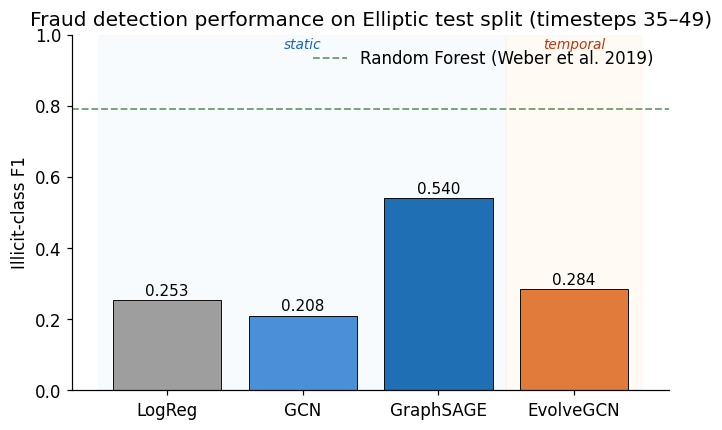

Saved -> /content/drive/MyDrive/graphshield/results/figures/fig1_f1_comparison.png


In [30]:
metrics = json.load(open(f'{RESULTS_DIR}/baselines.json'))
order = ['logreg', 'gcn', 'graphsage', 'evolve_gcn']  # add 'tgn' when ready
order = [m for m in order if m in metrics]

f1s    = [metrics[m]['illicit_f1'] for m in order]
labels = [NAMES[m] for m in order]
colors = [COLORS[m] for m in order]

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(labels, f1s, color=colors, edgecolor='black', linewidth=0.6)

# Reference lines
ax.axhline(0.79, color='#2e7d32', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Random Forest (Weber et al. 2019)')
ax.set_ylabel('Illicit-class F1')
ax.set_title('Fraud detection performance on Elliptic test split (timesteps 35–49)')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', frameon=False)

for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
            f'{v:.3f}', ha='center', fontsize=10)

# Visually group static vs temporal
ax.axvspan(-0.5, 2.5, color='#e3f2fd', alpha=0.25, zorder=0)
ax.axvspan(2.5, len(order)-0.5, color='#fff3e0', alpha=0.35, zorder=0)
ax.text(1, 0.96, 'static', ha='center', color='#1565c0', fontsize=9, style='italic')
ax.text(3 if len(order) > 3 else 2.5, 0.96, 'temporal',
        ha='center', color='#bf360c', fontsize=9, style='italic')

plt.savefig(f'{FIG_DIR}/fig1_f1_comparison.png')
plt.show()
print(f'Saved -> {FIG_DIR}/fig1_f1_comparison.png')

Figure 2 — EvolveGCN training instability
This is your most rhetorically valuable figure — visually supports your "training was unstable" claim from §3.2.

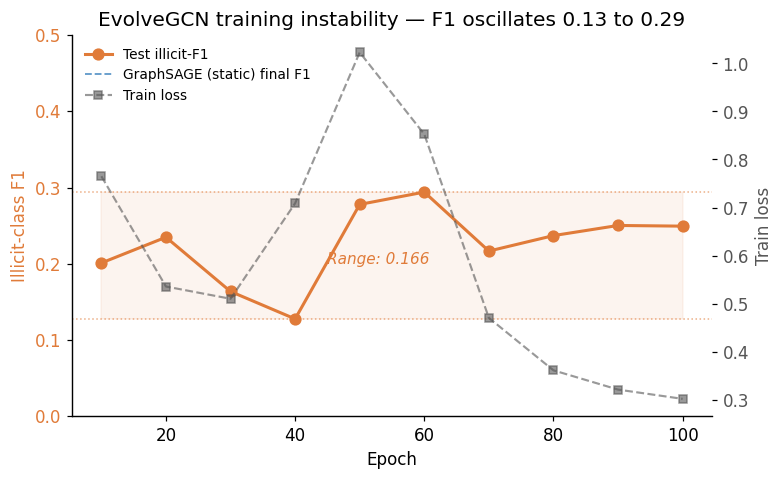

Saved -> /content/drive/MyDrive/graphshield/results/figures/fig2_evolve_gcn_instability.png


In [31]:
# Numbers from your actual EvolveGCN training log (cell 30 output)
epochs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
f1     = [0.2010, 0.2348, 0.1636, 0.1276, 0.2778, 0.2940, 0.2166, 0.2369, 0.2502, 0.2493]
loss   = [0.7651, 0.5355, 0.5100, 0.7088, 1.0230, 0.8525, 0.4702, 0.3610, 0.3209, 0.3016]

fig, ax1 = plt.subplots(figsize=(7.5, 4.5))

ax1.plot(epochs, f1, 'o-', color=COLORS['evolve_gcn'], linewidth=2,
         markersize=7, label='Test illicit-F1')
ax1.fill_between(epochs, [min(f1)]*len(epochs), [max(f1)]*len(epochs),
                 color=COLORS['evolve_gcn'], alpha=0.08)
ax1.axhline(max(f1), color=COLORS['evolve_gcn'], linestyle=':', linewidth=1, alpha=0.6)
ax1.axhline(min(f1), color=COLORS['evolve_gcn'], linestyle=':', linewidth=1, alpha=0.6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Illicit-class F1', color=COLORS['evolve_gcn'])
ax1.tick_params(axis='y', labelcolor=COLORS['evolve_gcn'])
ax1.set_ylim(0, 0.5)

# Reference: GraphSAGE final F1
ax1.axhline(0.6931, color=COLORS['graphsage'], linestyle='--', linewidth=1.2,
            alpha=0.7, label='GraphSAGE (static) final F1')

ax2 = ax1.twinx()
ax2.plot(epochs, loss, 's--', color='#555', linewidth=1.4,
         markersize=5, alpha=0.6, label='Train loss')
ax2.set_ylabel('Train loss', color='#555')
ax2.tick_params(axis='y', labelcolor='#555')
ax2.spines['top'].set_visible(False)

ax1.set_title('EvolveGCN training instability — F1 oscillates 0.13 to 0.29')
ax1.annotate(f'Range: {max(f1)-min(f1):.3f}',
             xy=(45, 0.20), fontsize=10, style='italic', color=COLORS['evolve_gcn'])

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False, fontsize=9)

plt.savefig(f'{FIG_DIR}/fig2_evolve_gcn_instability.png')
plt.show()
print(f'Saved -> {FIG_DIR}/fig2_evolve_gcn_instability.png')

Figure 3 — Precision-Recall curves
This needs the saved checkpoints to recompute probabilities. If you don't want to reload models, skip this and move to Figure 4 (works from saved metrics alone).

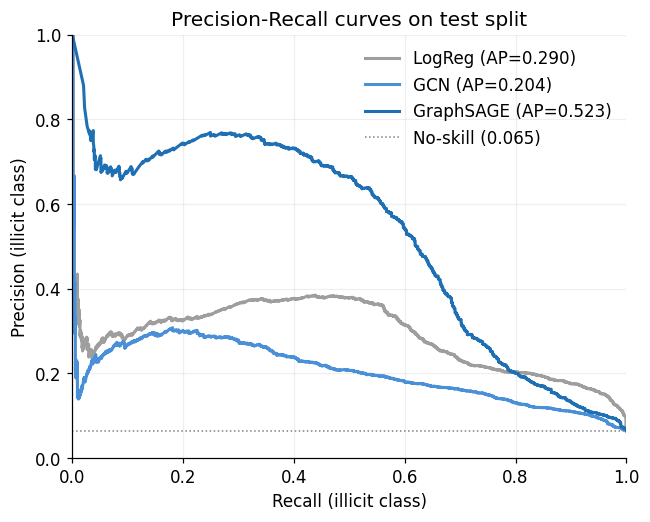

Saved -> /content/drive/MyDrive/graphshield/results/figures/fig3_pr_curves.png


In [32]:
# Rebuild data + masks (same loader as 02_baselines.ipynb)
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

DATA_DIR = f'{PROJECT_DIR}/data/raw/elliptic_bitcoin_dataset'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

features_raw = pd.read_csv(f'{DATA_DIR}/elliptic_txs_features.csv', header=None)
edges_raw    = pd.read_csv(f'{DATA_DIR}/elliptic_txs_edgelist.csv')
classes_raw  = pd.read_csv(f'{DATA_DIR}/elliptic_txs_classes.csv')

n_features = features_raw.shape[1] - 2
features_raw.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(n_features)]
txid_to_idx = {t: i for i, t in enumerate(features_raw['txId'].values)}
N = len(txid_to_idx)
timesteps = torch.tensor(features_raw['timestep'].values, dtype=torch.long)
x = torch.tensor(features_raw.iloc[:, 2:].values, dtype=torch.float)

valid = edges_raw['txId1'].isin(txid_to_idx) & edges_raw['txId2'].isin(txid_to_idx)
ec = edges_raw[valid]
edge_index = torch.tensor(np.stack([ec['txId1'].map(txid_to_idx).values,
                                     ec['txId2'].map(txid_to_idx).values]), dtype=torch.long)

def m(c):
    s = str(c).strip()
    return 1 if s == '1' else (0 if s == '2' else -1)
classes_raw['label'] = classes_raw['class'].apply(m)
ll = dict(zip(classes_raw['txId'], classes_raw['label']))
y = torch.tensor([ll.get(t, -1) for t in features_raw['txId'].values], dtype=torch.long)

labeled = (y != -1)
train_mask = labeled & (timesteps <= 34)
test_mask  = labeled & (timesteps >= 35)
data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask).to(device)
y_test = y[test_mask].numpy()

# Re-train LogReg quickly
X_train, X_test = x[train_mask].numpy(), x[test_mask].numpy()
y_train_np = y[train_mask].numpy()
sc = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
clf.fit(sc.transform(X_train), y_train_np)
probs_logreg = clf.predict_proba(sc.transform(X_test))[:, 1]

# Reload GCN + GraphSAGE
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden); self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, out_dim); self.dropout = dropout
    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, ei)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden=128, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden); self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, out_dim); self.dropout = dropout
    def forward(self, x, ei):
        h = F.relu(self.conv1(x, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, ei)); h = F.dropout(h, p=self.dropout, training=self.training)
        return self.conv3(h, ei)

def get_probs(model_cls, ckpt):
    m = model_cls(in_dim=data.x.shape[1]).to(device)
    m.load_state_dict(torch.load(f'{RESULTS_DIR}/{ckpt}'))
    m.eval()
    with torch.no_grad():
        out = m(data.x, data.edge_index)
        return F.softmax(out, dim=1)[:, 1][test_mask].cpu().numpy()

probs_gcn  = get_probs(GCN,        'gcn.pt')
probs_sage = get_probs(GraphSAGE,  'graphsage.pt')

# Plot
fig, ax = plt.subplots(figsize=(6.5, 5))
for name, probs in [('logreg', probs_logreg), ('gcn', probs_gcn), ('graphsage', probs_sage)]:
    p, r, _ = precision_recall_curve(y_test, probs)
    from sklearn.metrics import average_precision_score
    ap = average_precision_score(y_test, probs)
    ax.plot(r, p, color=COLORS[name], linewidth=2, label=f'{NAMES[name]} (AP={ap:.3f})')

baseline_pos_rate = (y_test == 1).mean()
ax.axhline(baseline_pos_rate, color='gray', linestyle=':', linewidth=1,
           label=f'No-skill ({baseline_pos_rate:.3f})')

ax.set_xlabel('Recall (illicit class)'); ax.set_ylabel('Precision (illicit class)')
ax.set_title('Precision-Recall curves on test split'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper right', frameon=False)
ax.grid(alpha=0.2)

plt.savefig(f'{FIG_DIR}/fig3_pr_curves.png')
plt.show()
print(f'Saved -> {FIG_DIR}/fig3_pr_curves.png')

Figure 4 — Confusion matricesRun after Figure 3 (uses the same probs_* variables). If you skipped Figure 3, run this with hard predictions only — change the threshold-0.5 logic.

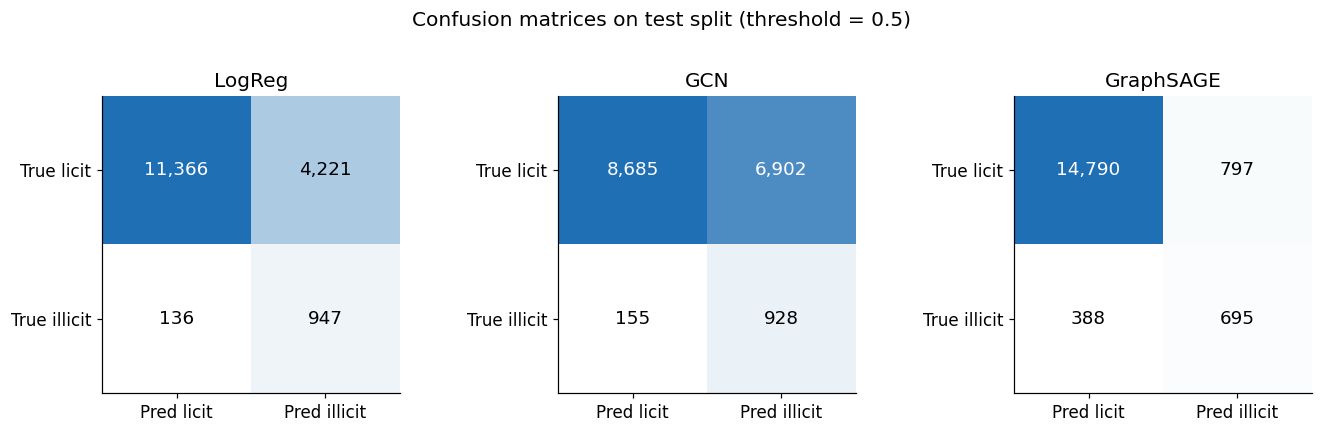

Saved -> /content/drive/MyDrive/graphshield/results/figures/fig4_confusion_matrices.png


In [33]:
from matplotlib.colors import LinearSegmentedColormap

models_probs = [
    ('logreg',    probs_logreg),
    ('gcn',       probs_gcn),
    ('graphsage', probs_sage),
]
# If EvolveGCN probs were saved, append here.

fig, axes = plt.subplots(1, len(models_probs), figsize=(4.2*len(models_probs), 3.8))
if len(models_probs) == 1: axes = [axes]

cmap = LinearSegmentedColormap.from_list('clean', ['#ffffff', '#1f6fb4'])

for ax, (name, probs) in zip(axes, models_probs):
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_test, preds, labels=[0, 1])
    im = ax.imshow(cm, cmap=cmap, aspect='equal')

    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            color = 'white' if v > cm.max()*0.55 else 'black'
            ax.text(j, i, f'{v:,}', ha='center', va='center', color=color, fontsize=12)

    ax.set_title(NAMES[name]); ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred licit', 'Pred illicit'])
    ax.set_yticklabels(['True licit', 'True illicit'])
    ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('Confusion matrices on test split (threshold = 0.5)', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_confusion_matrices.png')
plt.show()
print(f'Saved -> {FIG_DIR}/fig4_confusion_matrices.png')

Figure 5 — GNNExplainer subgraph for a true-positive
This is the explainability deliverable. Picks the highest-confidence true-positive illicit prediction from GraphSAGE and visualizes which edges drove it.

Target node 157681 | P(illicit)=1.000 | 2-hop edges: 107


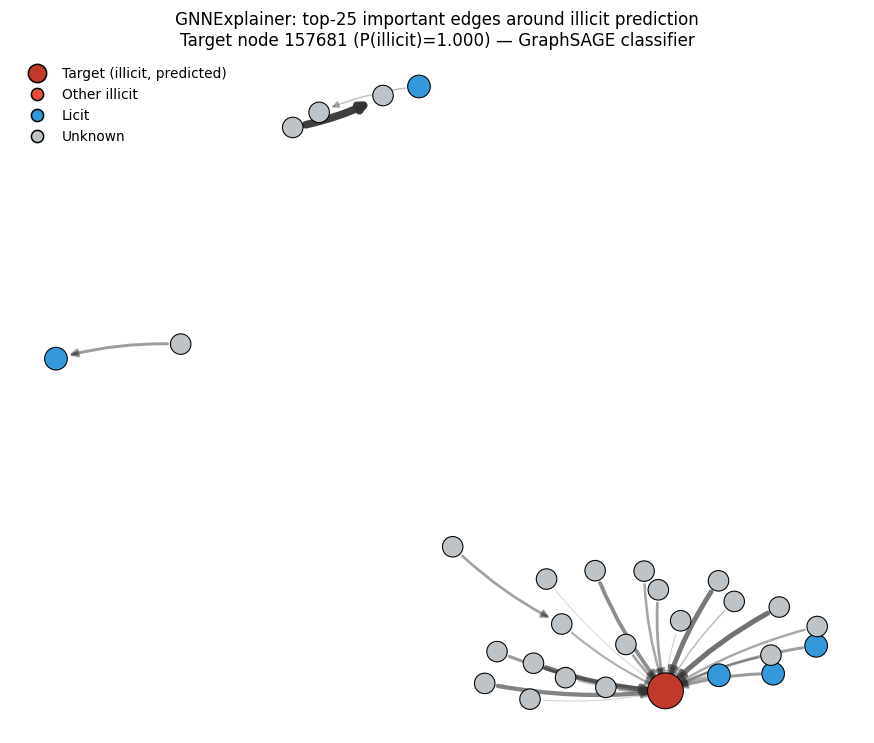

In [34]:
from torch_geometric.explain import Explainer, GNNExplainer
import networkx as nx
from matplotlib.lines import Line2D

# Reload best GraphSAGE
model = GraphSAGE(in_dim=data.x.shape[1]).to(device)
model.load_state_dict(torch.load(f'{RESULTS_DIR}/graphsage.pt'))
model.eval()

with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs_all = F.softmax(out, dim=1)[:, 1]

# Pre-filter to true positives whose 2-hop neighborhood has >= 8 edges
ei_np = data.edge_index.cpu().numpy()
test_idx_cpu = test_mask.nonzero(as_tuple=True)[0].cpu().numpy()
preds_cpu = out.argmax(dim=1).cpu().numpy()
y_np = y.cpu().numpy()

candidates = []
for n in test_idx_cpu:
    if y_np[n] != 1 or preds_cpu[n] != 1:  # only true-positive illicit
        continue
    h1 = set(ei_np[1, ei_np[0] == n].tolist()) | set(ei_np[0, ei_np[1] == n].tolist())
    h2 = set()
    for m in h1:
        h2 |= set(ei_np[1, ei_np[0] == m].tolist()) | set(ei_np[0, ei_np[1] == m].tolist())
    keep = {int(n)} | h1 | h2
    n_edges = int((np.isin(ei_np[0], list(keep)) & np.isin(ei_np[1], list(keep))).sum())
    if n_edges >= 8:
        candidates.append((int(n), n_edges, float(probs_all[n].cpu())))

# Pick highest-confidence among candidates with rich neighborhoods
candidates.sort(key=lambda c: (-c[2], -c[1]))
target_node, n_edges_total, target_prob = candidates[0]
print(f'Target node {target_node} | P(illicit)={target_prob:.3f} | 2-hop edges: {n_edges_total}')

# Run GNNExplainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=300),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(mode='multiclass_classification', task_level='node', return_type='log_probs'),
)
explanation = explainer(data.x, data.edge_index, index=target_node)
edge_mask = explanation.edge_mask.cpu().numpy()

# Build subgraph
hop1 = set(ei_np[1, ei_np[0] == target_node].tolist()) | set(ei_np[0, ei_np[1] == target_node].tolist())
hop2 = set()
for n in hop1:
    hop2 |= set(ei_np[1, ei_np[0] == n].tolist()) | set(ei_np[0, ei_np[1] == n].tolist())
keep = {target_node} | hop1 | hop2
keep_arr = np.array(sorted(keep))
edge_in = np.isin(ei_np[0], keep_arr) & np.isin(ei_np[1], keep_arr)

# Filter to top-K most important edges (cleaner viz)
edge_in_idx = np.where(edge_in)[0]
imps_in = edge_mask[edge_in_idx]
TOP_K = min(25, len(edge_in_idx))
top = edge_in_idx[np.argsort(-imps_in)[:TOP_K]]

G = nx.DiGraph()
nodes_in_top = set([target_node])
for i in top:
    u, v = int(ei_np[0, i]), int(ei_np[1, i])
    G.add_edge(u, v, importance=float(edge_mask[i]))
    nodes_in_top.update([u, v])
for n in nodes_in_top:
    if n not in G: G.add_node(n)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=7, k=1.2, iterations=200)

node_colors = []
node_sizes = []
for n in G.nodes():
    if n == target_node:           node_colors.append('#c0392b'); node_sizes.append(550)
    elif y_np[n] == 1:             node_colors.append('#e74c3c'); node_sizes.append(220)
    elif y_np[n] == 0:             node_colors.append('#3498db'); node_sizes.append(220)
    else:                          node_colors.append('#bdc3c7'); node_sizes.append(180)

edges = list(G.edges(data=True))
imps = np.array([e[2]['importance'] for e in edges])
imps_norm = (imps - imps.min()) / (imps.max() - imps.min() + 1e-9)
widths = 0.5 + imps_norm * 4.5
alphas = 0.25 + imps_norm * 0.7

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.7, ax=ax)
for (u, v, d), w, a in zip(edges, widths, alphas):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=w, alpha=a,
                           edge_color='#333', arrows=True, arrowsize=10,
                           connectionstyle='arc3,rad=0.08', ax=ax)

ax.set_title(f'GNNExplainer: top-{TOP_K} important edges around illicit prediction\n'
             f'Target node {target_node} (P(illicit)={target_prob:.3f}) — '
             f'GraphSAGE classifier', fontsize=11)

legend_items = [
    Line2D([0],[0], marker='o', color='w', label='Target (illicit, predicted)',
           markerfacecolor='#c0392b', markersize=12, markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', label='Other illicit',
           markerfacecolor='#e74c3c', markersize=8, markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', label='Licit',
           markerfacecolor='#3498db', markersize=8, markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', label='Unknown',
           markerfacecolor='#bdc3c7', markersize=8, markeredgecolor='black'),
]
ax.legend(handles=legend_items, loc='upper left', frameon=False, fontsize=9)
ax.axis('off')

plt.savefig(f'{FIG_DIR}/fig5_explanation_subgraph.png')
plt.show()

# Phase 3b — TGN (Temporal Graph Network)

Continuous-time temporal GNN with per-node memory modules.
Reference: Rossi et al. 2020.

Adapting TGN to Elliptic requires faking continuous time from 49 discrete
timesteps — we treat each transaction edge as an event timestamped by its
destination node's timestep. Memory state at each node's timestep is used
for classification.

Expected illicit-F1: ~0.55–0.70 if it trains well. Memory can collapse;
if F1 stays at 0 after 5 epochs, lower learning rate and retry.